In [1]:
import pandas as pd

# 1. Membaca data kuesioner dari file Excel Anda
file_name = 'kuisioner usability user (Jawaban).xlsx'
df = pd.read_excel(file_name)

# 2. Mengambil 10 kolom pertanyaan (Dimulai dari kolom ke-3)
kolom_pertanyaan = df.columns[3:]

# 3. Membersihkan data 
# (Memastikan semua teks menjadi angka, dan mengisi teks yang typo dengan nilai median)
for col in kolom_pertanyaan:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df[kolom_pertanyaan] = df[kolom_pertanyaan].fillna(df[kolom_pertanyaan].median())

# 4. Menentukan parameter perhitungan
jumlah_responden = len(df)
max_skor_per_item = jumlah_responden * 5

# Membuat list kosong untuk menampung data tabel
hasil_tabel = []

# 5. Melakukan iterasi/perulangan untuk menghitung tiap pertanyaan
for i, col in enumerate(kolom_pertanyaan):
    total_skor_item = df[col].sum()
    persentase = (total_skor_item / max_skor_per_item) * 100
    
    # Menentukan Kategori Kelayakan
    if persentase <= 20:
        kategori = "Sangat Tidak Layak"
    elif persentase <= 40:
        kategori = "Tidak Layak"
    elif persentase <= 60:
        kategori = "Cukup Layak"
    elif persentase <= 80:
        kategori = "Layak"
    else:
        kategori = "Sangat Layak"
        
    # Memasukkan hasil ke dalam list
    hasil_tabel.append({
        "No": i + 1,
        "Pernyataan": col.strip(),
        "Skor (%)": f"{persentase:.2f}%",
        "Kategori": kategori
    })

# 6. Menampilkan hasil ke dalam bentuk tabel (DataFrame)
df_hasil = pd.DataFrame(hasil_tabel)

# Mengatur agar lebar kolom teks menyesuaikan saat ditampilkan
pd.set_option('display.max_colwidth', None)

# Menampilkan tabel
display(df_hasil)

,No,Pernyataan,Skor (%),Kategori
0,1,Aplikasi uji kompetensi mudah dipahami dan digunakan,88.00%,Sangat Layak
1,2,Proses login dan navigasi menu berjalan dengan jelas,86.40%,Sangat Layak
2,3,Tampilan aplikasi menarik dan nyaman digunakan,88.00%,Sangat Layak
3,4,Tata letak menu dan informasi tersusun dengan rapi,91.20%,Sangat Layak
4,5,Aplikasi berjalan dengan aman tanpa gangguan,85.60%,Sangat Layak
5,6,Waktu respon sistem saat mengerjakan ujian sudah memadai,84.00%,Sangat Layak
6,7,Fitur yang disediakan sudah sesuai dengan kebutuhan uji kompetensi,84.80%,Sangat Layak
7,8,Sistem urutan soal yang diacak membuat saya harus lebih mandiri (tidak bisa mencontek) dalam mengerjakan ujian,88.00%,Sangat Layak
8,9,Hasil ujian dan umpan balik dapat diakses dengan jelas,90.40%,Sangat Layak
9,10,"Secara keseluruhan, saya puas menggunakan aplikasi uji kompetensi",90.40%,Sangat Layak


Matplotlib is building the font cache; this may take a moment.


Berhasil! Gambar telah disimpan di folder Downloads dengan nama: grafik_hasil_usability.png


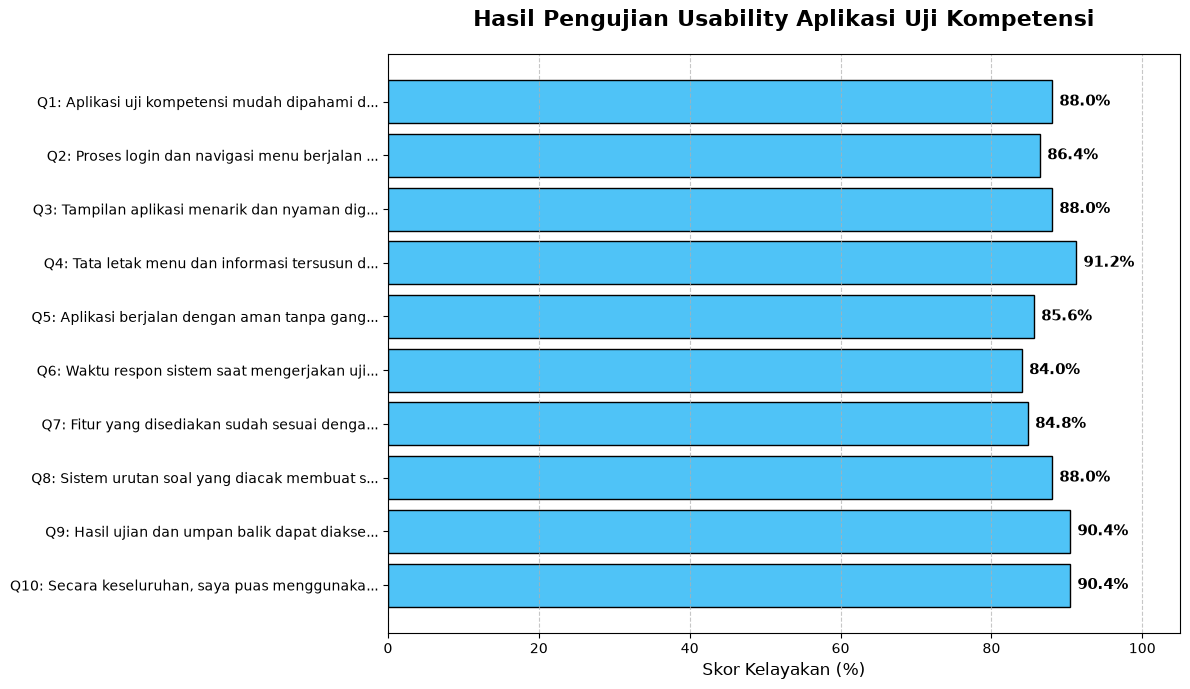

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Membaca dan membersihkan data (sama seperti sebelumnya)
file_name = 'kuisioner usability user (Jawaban).xlsx'
df = pd.read_excel(file_name)
kolom_pertanyaan = df.columns[3:]

for col in kolom_pertanyaan:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df[kolom_pertanyaan] = df[kolom_pertanyaan].fillna(df[kolom_pertanyaan].median())

# 2. Menghitung persentase per pertanyaan
jumlah_responden = len(df)
max_skor = jumlah_responden * 5
persentase_list = [(df[col].sum() / max_skor) * 100 for col in kolom_pertanyaan]

# Memotong teks pertanyaan agar tidak terlalu panjang di grafik
label_grafik = [f"Q{i+1}: {col.strip()[:40]}..." if len(col) > 40 else f"Q{i+1}: {col.strip()}" for i, col in enumerate(kolom_pertanyaan)]

# 3. Membuat Visualisasi Grafik Batang Horizontal
plt.figure(figsize=(12, 7)) # Mengatur ukuran kanvas
bars = plt.barh(label_grafik, persentase_list, color='#4FC3F7', edgecolor='black')

# 4. Menambahkan angka persentase di ujung setiap batang
for bar in bars:
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.1f}%', 
             va='center', ha='left', fontsize=11, fontweight='bold')

# 5. Mempercantik tampilan grafik
plt.title('Hasil Pengujian Usability Aplikasi Uji Kompetensi', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Skor Kelayakan (%)', fontsize=12)
plt.xlim(0, 105) # Batas sumbu X (0 sampai 105 agar angka di ujung tidak terpotong)
plt.gca().invert_yaxis() # Membalik urutan agar Q1 berada di paling atas
plt.grid(axis='x', linestyle='--', alpha=0.7) # Menambah garis bantu vertikal
plt.tight_layout()

# 6. Menyimpan grafik menjadi file gambar (PNG)
nama_file_gambar = 'grafik_hasil_usability.png'
plt.savefig(nama_file_gambar, dpi=300) # dpi=300 agar gambar tidak pecah saat di-zoom di Word
print(f"Berhasil! Gambar telah disimpan di folder Downloads dengan nama: {nama_file_gambar}")

# 7. Menampilkan grafik di Jupyter Notebook
plt.show()

Total Responden: 25


,No,Pernyataan,SS,S,N,TS,STS,Skor,Persentase (%),Kategori
0,1,Aplikasi uji kompetensi mudah dipahami dan dig...,12,11,2,0,0,110,88.0,Sangat Layak
1,2,Proses login dan navigasi menu berjalan dengan...,11,11,3,0,0,108,86.4,Sangat Layak
2,3,Tampilan aplikasi menarik dan nyaman digunakan...,13,9,3,0,0,110,88.0,Sangat Layak
3,4,Tata letak menu dan informasi tersusun dengan ...,17,5,3,0,0,114,91.2,Sangat Layak
4,5,Aplikasi berjalan dengan aman tanpa gangguan...,9,14,2,0,0,107,85.6,Sangat Layak
5,6,Waktu respon sistem saat mengerjakan ujian sud...,9,12,4,0,0,105,84.0,Sangat Layak
6,7,Fitur yang disediakan sudah sesuai dengan kebu...,9,13,3,0,0,106,84.8,Sangat Layak
7,8,Sistem urutan soal yang diacak membuat saya ha...,13,10,1,1,0,110,88.0,Sangat Layak
8,9,Hasil ujian dan umpan balik dapat diakses deng...,15,8,2,0,0,113,90.4,Sangat Layak
9,10,"Secara keseluruhan, saya puas menggunakan apli...",14,10,1,0,0,113,90.4,Sangat Layak


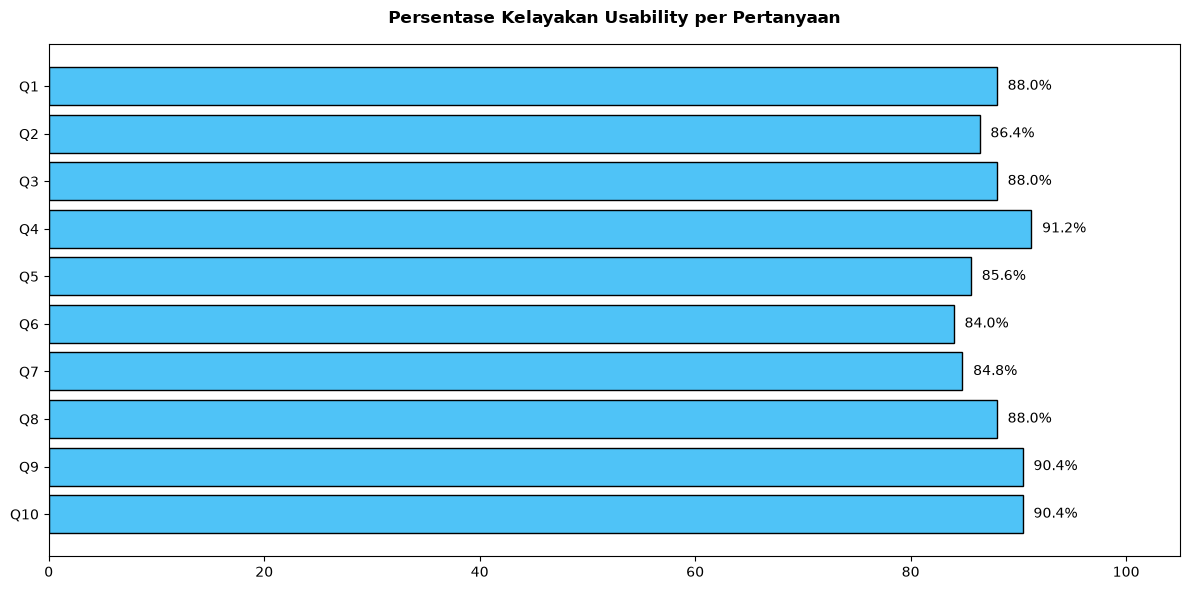

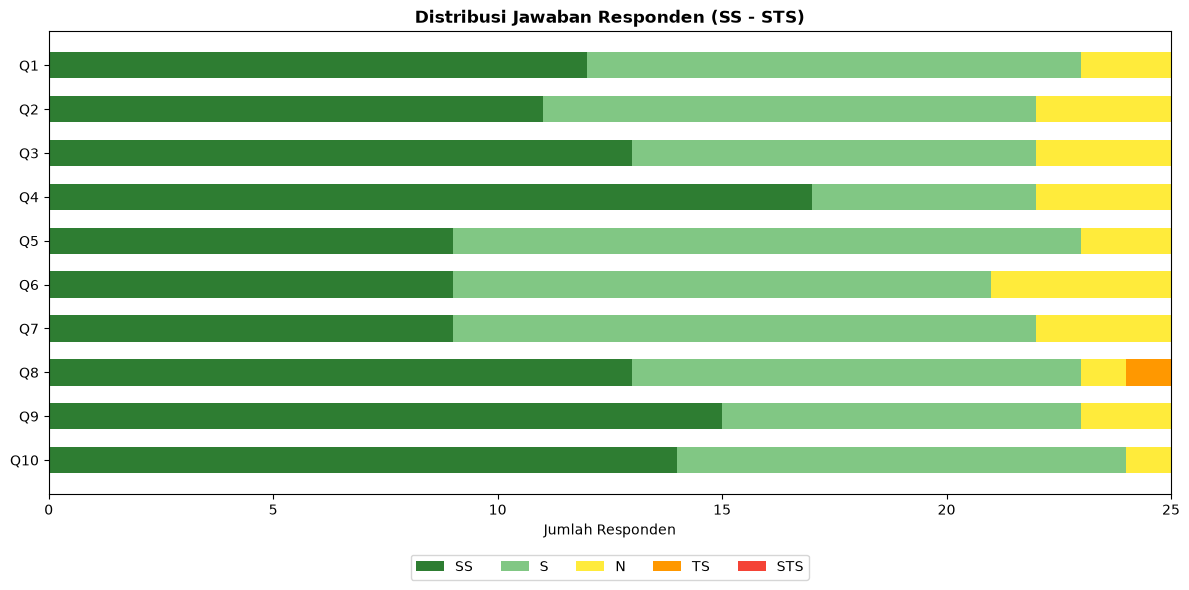

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. MEMBACA & MEMBERSIHKAN DATA ---
file_name = 'kuisioner usability user (Jawaban).xlsx'
df = pd.read_excel(file_name)
kolom_pertanyaan = df.columns[3:]

for col in kolom_pertanyaan:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df[kolom_pertanyaan] = df[kolom_pertanyaan].fillna(df[kolom_pertanyaan].median())

jumlah_responden = len(df)
print(f"Total Responden: {jumlah_responden}")

# --- 2. KALKULASI TABEL SS-STS & PERSENTASE ---
hasil = []
for i, col in enumerate(kolom_pertanyaan):
    counts = df[col].value_counts()
    
    # Mengambil frekuensi jawaban (default 0 jika tidak ada yang jawab)
    ss = int(counts.get(5, 0))
    s = int(counts.get(4, 0))
    n = int(counts.get(3, 0))
    ts = int(counts.get(2, 0))
    sts = int(counts.get(1, 0))
    
    total_skor = df[col].sum()
    max_skor = jumlah_responden * 5
    persentase = (total_skor / max_skor) * 100
    
    # Logika Kategori
    if persentase <= 20:
        kategori = "Sangat Tidak Layak"
    elif persentase <= 40:
        kategori = "Tidak Layak"
    elif persentase <= 60:
        kategori = "Cukup Layak"
    elif persentase <= 80:
        kategori = "Layak"
    else:
        kategori = "Sangat Layak"

    hasil.append({
        "No": i+1,
        "Pernyataan": col.strip()[:60] + "...", 
        "SS": ss, "S": s, "N": n, "TS": ts, "STS": sts,
        "Skor": total_skor,
        "Persentase (%)": round(persentase, 2),
        "Kategori": kategori
    })

df_hasil = pd.DataFrame(hasil)
display(df_hasil)

# --- 3. GENERATE GRAFIK 1 (PERSENTASE KELAYAKAN) ---
plt.figure(figsize=(12, 6))
labels = [f"Q{row['No']}" for _, row in df_hasil.iterrows()]
bars = plt.barh(labels, df_hasil['Persentase (%)'], color='#4FC3F7', edgecolor='black')

for bar in bars:
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.1f}%', va='center', fontsize=10)

plt.title('Persentase Kelayakan Usability per Pertanyaan', pad=15, fontweight='bold')
plt.xlim(0, 105)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('grafik_persentase.png', dpi=300)
plt.show()

# --- 4. GENERATE GRAFIK 2 (DISTRIBUSI SS-STS) ---
width = 0.6
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(labels, df_hasil['SS'], width, label='SS', color='#2e7d32')
ax.barh(labels, df_hasil['S'], width, left=df_hasil['SS'], label='S', color='#81c784')
ax.barh(labels, df_hasil['N'], width, left=df_hasil['SS']+df_hasil['S'], label='N', color='#ffeb3b')
ax.barh(labels, df_hasil['TS'], width, left=df_hasil['SS']+df_hasil['S']+df_hasil['N'], label='TS', color='#ff9800')
ax.barh(labels, df_hasil['STS'], width, left=df_hasil['SS']+df_hasil['S']+df_hasil['N']+df_hasil['TS'], label='STS', color='#f44336')

ax.set_xlabel('Jumlah Responden')
ax.set_title('Distribusi Jawaban Responden (SS - STS)', fontweight='bold')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=5)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('grafik_distribusi.png', dpi=300)
plt.show()